# Chronos-2 Zero-Shot Forex Forecast

Loads raw forex price data, runs `amazon/chronos-2` (120 M params, ~480 MB bfloat16),
and plots a dark-theme fan chart showing the last `context_bars_shown` candles plus
the next `prediction_length` bars with nested probability bands.

No feature engineering, no normalisation — Chronos receives raw close prices only.

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from Pipeline.pipeline import ForexDataLoader
from Chronos.chronos_inference import ChronosForecaster
from Chronos.chronos_plots import plot_forecast, save_png

HISTDATA_DIR = PROJECT_ROOT / 'histdata'
OUT_PNG      = PROJECT_ROOT / 'chronos_forecast.png'
OUT_FUTURE   = PROJECT_ROOT / 'chronos_forecast_future.png'

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060
VRAM    : 8.6 GB


## Cell 2 — Configuration

**`context_end`** is the cutoff datetime.
The model is fed `context_length` bars of raw close price **before** this point
and predicts `prediction_length` bars **after** it.
Any bars that exist after `context_end` in the loaded data are shown as faded ground-truth candles.

Run **Cell 3** first to see the full date range, then set `context_end` to any datetime within it.

In [11]:
CFG = dict(
    pair               = 'EURUSD',
    years              = [2022, 2023],
    timeframe          = 'H1',              # H1 | H4 | M15 | M30 | M5
    context_end        = '2023-08-31 00:00', # ← any ISO datetime in the loaded range
    context_length     = 512,               # bars fed to Chronos (max 8192)
    prediction_length  = 24,                # bars to predict (48 H1 ≈ 2 trading days)
    context_bars_shown = 504,                # candles shown in chart before 'now'
    device             = 'auto',            # 'auto' | 'cuda' | 'cpu'
    dtype              = torch.bfloat16,    # use torch.float32 on CPU
)

_TF_MAP = {'M5': '5min', 'M15': '15min', 'M30': '30min',
           'H1': '1h',   'H4': '4h',     'D1': '1D'}

## Cell 3 — Load & Resample Data

In [ ]:
loader   = ForexDataLoader()
df_m1    = loader.load_and_merge(HISTDATA_DIR, pair=CFG['pair'], years=CFG['years'], weekends="filled")

tf_pd    = _TF_MAP.get(CFG['timeframe'], CFG['timeframe'])
price_df = (
    df_m1
    .resample(tf_pd)
    .agg({'open': 'first', 'high': 'max', 'low': 'min',
          'close': 'last', 'volume': 'sum'})
    .dropna()
)
price_df.attrs['pair'] = CFG['pair']

print(f"Pair      : {CFG['pair']}")
print(f"Timeframe : {CFG['timeframe']}  ({len(price_df):,} bars)")
print(f"Date range: {price_df.index[0]}  →  {price_df.index[-1]}")
print()
print(f"context_end = {CFG['context_end']!r}")
print(f"  model receives {CFG['context_length']} bars before this point")
print(f"  predicts {CFG['prediction_length']} bars after this point")
#if wanna log:
#price_df['close'] = np.log(price_df['close'] / price_df['close'].shift(1))                                                                                                                              
#price_df = price_df.dropna() 

[Loader] EURUSD: 372,865 M1 bars  |  2022-01-02 17:03:00 → 2022-12-30 16:58:00
[Loader] EURUSD: 322,638 M1 bars  |  2023-01-01 17:04:00 → 2023-12-29 16:58:00
[Loader] Merged EURUSD: 748,379 M1 bars  |  2022-01-03 00:00:00 → 2023-12-29 16:58:00
Pair      : EURUSD
Timeframe : H1  (12,473 bars)
Date range: 2022-01-03 00:00:00  →  2023-12-29 16:00:00

context_end = '2023-08-31 00:00'
  model receives 512 bars before this point
  predicts 24 bars after this point


## Cell 4 — Load Chronos-2 Model

Weights (~480 MB bfloat16) are downloaded to `Chronos/model/` on first run.

In [13]:
forecaster = ChronosForecaster(
    context_length = CFG['context_length'],
    device         = CFG['device'],
    dtype          = CFG['dtype'],
)
forecaster.load()

[Chronos] Loading amazon/chronos-2
          cache  → /home/anton/Trade_bot/Chronos/model
[Chronos] Ready on cuda:0
          quantiles : 21 levels  (0.01 … 0.99)
          ctx window: 8192


## Cell 5 — Run Forecast

In [14]:
result = forecaster.forecast_from_df(
price_df,
context_end       = CFG['context_end'],
prediction_length = CFG['prediction_length'],

)
result['timeframe'] = CFG['timeframe']

fc         = result['forecast']
qs         = fc['quantiles']
gt_df      = result['ground_truth_df']
last_close = float(result['context_df']['close'].iloc[-1])
prob_up    = ChronosForecaster.prob_above(fc, last_close)

print(f"Context ends : {result['context_end']}")
print(f"Forecast     : {result['forecast_start']}  →  {result['forecast_timestamps'][-1]}")
gt_info = f"{len(gt_df)} bars available" if gt_df is not None else "none (genuine future)"
print(f"Ground truth : {gt_info}")
print(f"Last close   : {last_close:.5f}")

Context ends : 2023-08-31 00:00:00
Forecast     : 2023-08-31 01:00:00  →  2023-09-01 00:00:00
Ground truth : 24 bars available
Last close   : 1.09185


## Cell 6 — Forecast Summary Table

Quantile values and directional probability at four horizons.
`in P10–P90` shows whether the actual close was inside the central probability band.

In [15]:
pred_len = result['prediction_length']
horizons = [pred_len // 4, pred_len // 2, 3 * pred_len // 4, pred_len - 1]

header = f"{'Timestamp':>16}  {'P05':>8} {'P25':>8} {'P50':>8} {'P75':>8} {'P95':>8}  {'P(up)':>6}"
if gt_df is not None:
    header += f"  {'Actual':>9}  in P10-P90"
print(header)
print('-' * len(header))

for h in horizons:
    ts  = result['forecast_timestamps'][h].strftime('%Y-%m-%d %H:%M')
    row = f"{ts:>16}  "
    for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
        row += f"{qs[q][h]:>8.5f} "
    row += f"  {prob_up[h]:>6.1%}"
    if gt_df is not None and h < len(gt_df):
        actual  = float(gt_df['close'].iloc[h])
        in_band = qs[0.10][h] <= actual <= qs[0.90][h]
        row += f"  {actual:>9.5f}  {'yes' if in_band else 'no'}"
    print(row)

print()
print(f"Last close : {last_close:.5f}")
print(f"P50 final  : {qs[0.50][-1]:.5f}  ({prob_up[-1]:.1%} prob up)")

       Timestamp       P05      P25      P50      P75      P95   P(up)     Actual  in P10-P90
---------------------------------------------------------------------------------------------
2023-08-31 07:00   1.08594  1.09375  1.09375  1.09375  1.09375    81.2%    1.08682  yes
2023-08-31 13:00   1.08594  1.08594  1.09375  1.09375  1.09375    71.2%    1.08488  no
2023-08-31 19:00   1.08594  1.08594  1.09375  1.09375  1.10156    71.2%    1.08424  no
2023-09-01 00:00   1.08594  1.08594  1.09375  1.09375  1.10156    66.2%    1.08464  no

Last close : 1.09185
P50 final  : 1.09375  (66.2% prob up)


## Cell 7 — Forecast Chart

- **Teal / red candles** — last `context_bars_shown` bars of history
- **Coloured percentile lines** — P05 (red) · P25 (orange) · P50 (gold, bold) · P75 (light teal) · P95 (teal)
- **Faded candles** — ground-truth actuals when they exist in the loaded data
- **Bottom panel** — P(price > last close) at each step, teal/red fill around the 50 % line


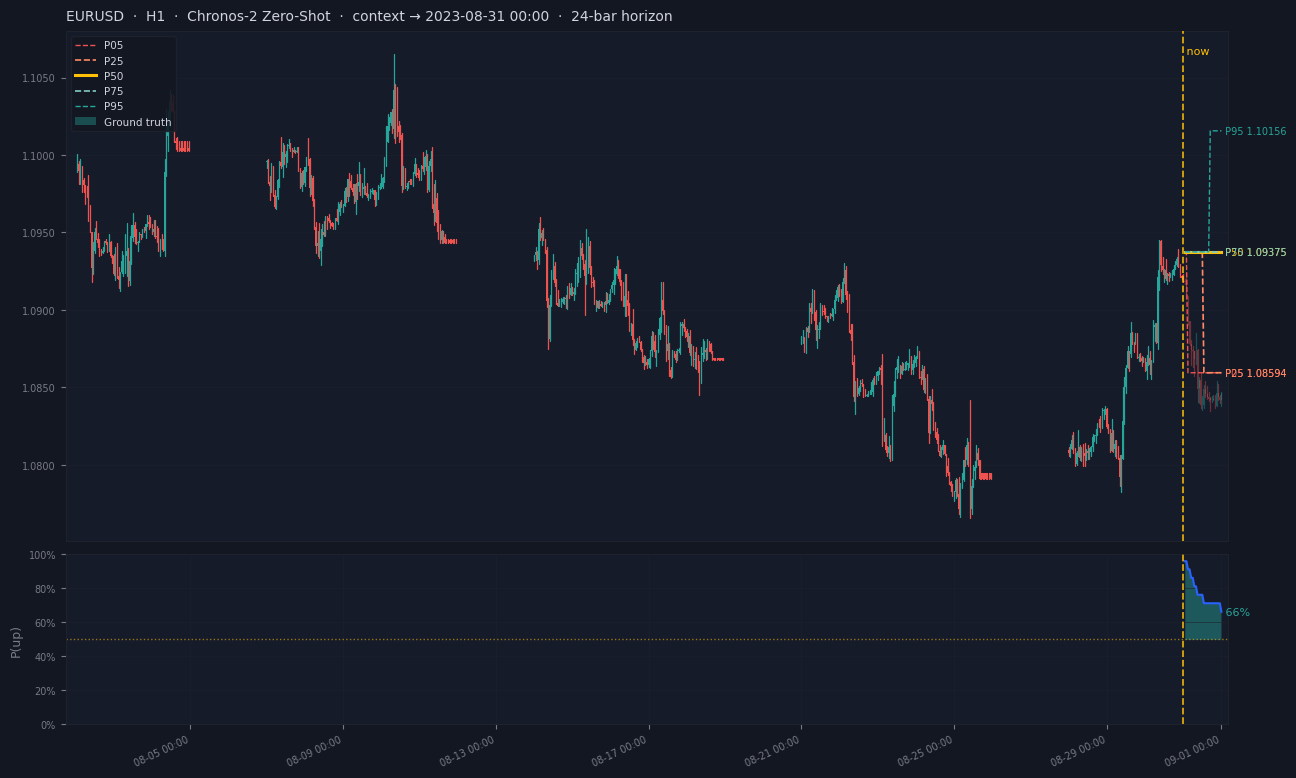

[Chronos] Saved → /home/anton/Trade_bot/chronos_forecast.png
Saved → /home/anton/Trade_bot/chronos_forecast.png


In [16]:
%matplotlib inline

fig = plot_forecast(result, context_bars_shown=CFG['context_bars_shown'])
plt.show()
save_png(fig, str(OUT_PNG))
print(f'Saved → {OUT_PNG}')